In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
from matplotlib.patches import Polygon

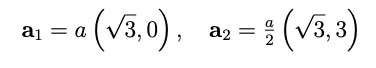

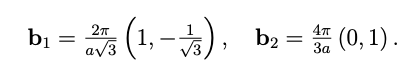

In [2]:
mpl.rcParams.update({
    "text.usetex": True,                
    "font.family": "serif",     
    "font.serif": ["Computer Modern"],  
    "axes.labelsize": 14,
    "font.size": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
})

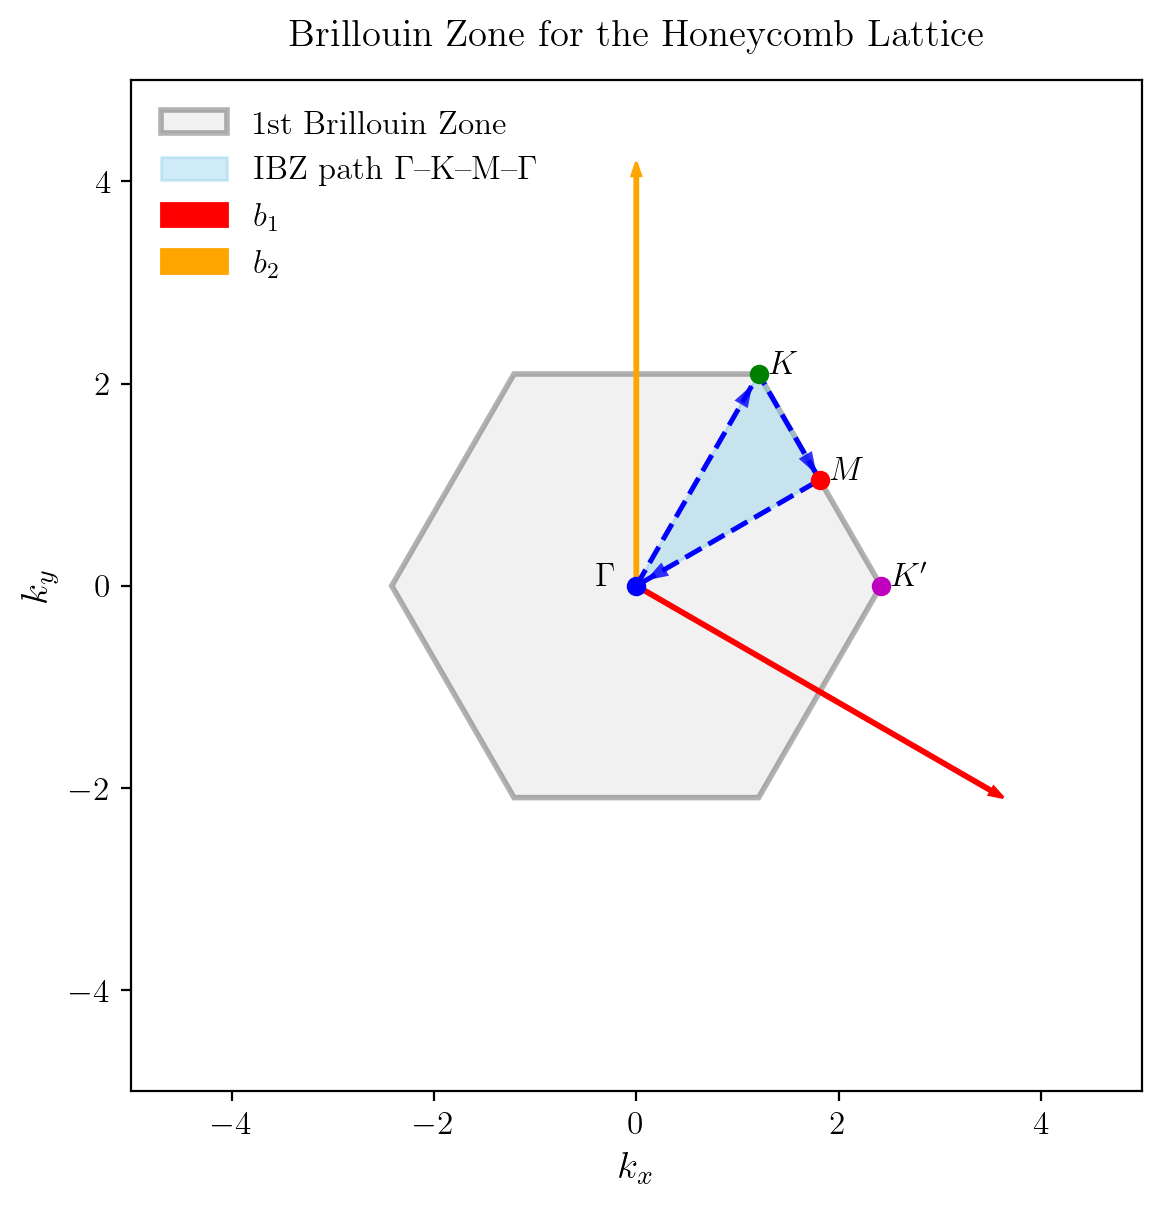

In [5]:
a = 1.0  # lattice constant

# --- Reciprocal lattice vectors ---
b1 = (2*np.pi/(a*np.sqrt(3))) * np.array([1, -1/np.sqrt(3)])
b2 = (4*np.pi/(3*a)) * np.array([0, 1])

# --- Real space lattice vectors ---
a1 = (a*np.array([np.sqrt(3), 0]))
a2 = (a/2 * np.array([np.sqrt(3), 3]))

# --- nearest reciprocal lattice vectors ---
G_list = [b1, -b1, b2, -b2, b1+b2, -(b1+b2)]

# --- Construct 1st BZ (Wigner–Seitz) ---
def line_params(G):
    n = G
    c = 0.5 * np.dot(G, G)
    return n, c

def intersect(n1, c1, n2, c2):
    M = np.vstack([n1, n2])
    rhs = np.array([c1, c2])
    return np.linalg.solve(M, rhs)

lines = [line_params(Gv) for Gv in G_list]
order = [0, 4, 2, 1, 5, 3]
verts = [intersect(*lines[order[i]], *lines[order[(i + 1) % 6]]) for i in range(6)]
verts = np.array(verts)

# --- High-symmetry points ---
G = np.array([0, 0])
Kp = (2*b1 + b2) / 3.0
K = (b1 + 2*b2) / 3.0
M = 0.5 * (b1 + b2)
path = np.vstack([G, K, M, G]) #for path
ibz_path = np.vstack([G, K, M, G])  # for shading

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 12))

# Fill BZ with light shading
bz_patch = Polygon(verts, closed=True, facecolor='lightgray', alpha=0.3, edgecolor='black', lw=2, label='1st Brillouin Zone')
ax.add_patch(bz_patch)

# Shade the IBZ path area
ax.fill(ibz_path[:,0], ibz_path[:,1], color='skyblue', alpha=0.4, label=r'IBZ path $\Gamma$–K–M–$\Gamma$')

# Plot IBZ path with arrows
ax.plot(path[:,0], path[:,1], 'b--', lw=1.8)
for i in range(len(path) - 1):
    start, end = path[i], path[i+1]
    mid = start + 0.7 * (end - start)
    delta = 0.25 * (end - start)
    ax.arrow(mid[0], mid[1], delta[0], delta[1],
             shape='full', lw=0, length_includes_head=True,
             head_width=0.15, color='b', alpha=0.8)

# Reciprocal vectors
ax.arrow(0, 0, b1[0], b1[1], color='r', width=0.03, length_includes_head=True, label='$b_1$')
ax.arrow(0, 0, b2[0], b2[1], color='orange', width=0.03, length_includes_head=True, label='$b_2$')

# High-symmetry points
ax.plot(G[0], G[1], 'bo'); ax.text(G[0]-0.4, G[1], r'$\Gamma$', fontsize=12)
ax.plot(K[0], K[1], 'go'); ax.text(K[0]+0.1, K[1], r"$K$", fontsize=12)
ax.plot(Kp[0], Kp[1], 'mo'); ax.text(Kp[0]+0.1, Kp[1], r"$K^{\prime}$", fontsize=12)
ax.plot(M[0], M[1], 'ro'); ax.text(M[0]+0.1, M[1], r'$M$', fontsize=12)

# Axes formatting
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_title('Brillouin Zone for the Honeycomb Lattice', pad=12)
ax.legend(frameon=False, loc='upper left')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
# Remove grid and tighten layout
ax.grid(False)
plt.tight_layout()
plt.show()

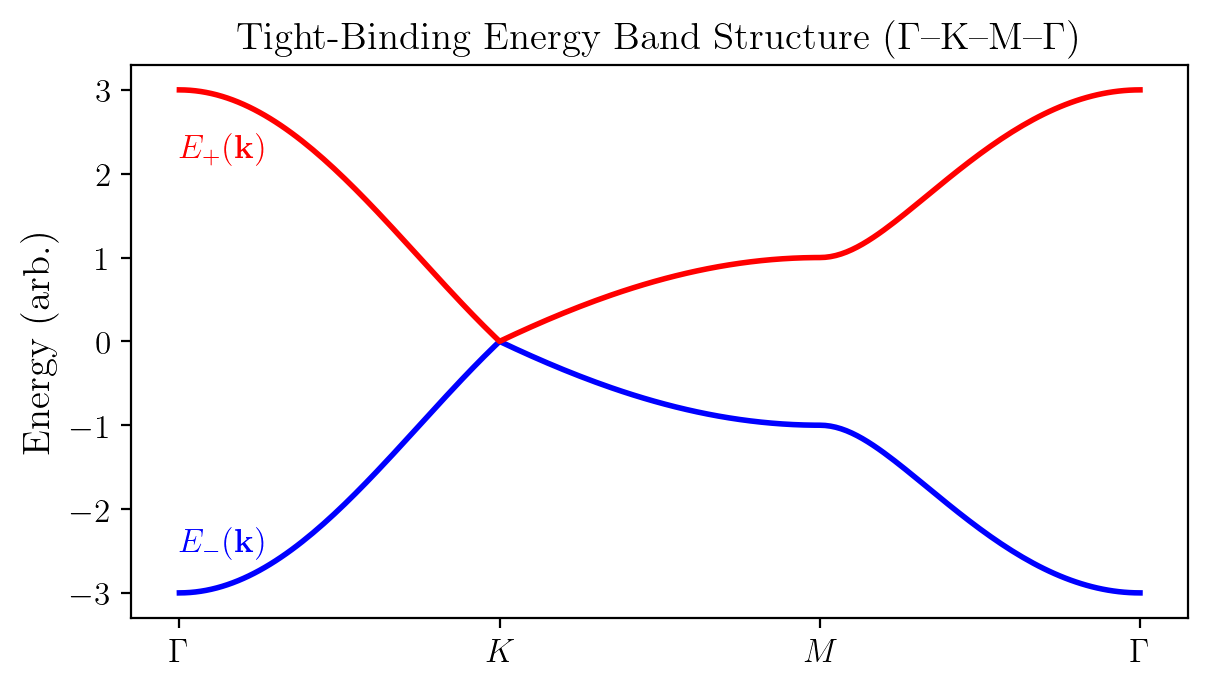

In [7]:
def f_k(kx, ky):
    # compute the structure factor f(k) at given kx, ky
    return 1 + np.exp(1j * (kx * a1[0] + ky * a1[1])) + np.exp(1j * (kx * a2[0] + ky * a2[1]))
 
def energies(kx, ky, t=1.0):
    # compute the energy eigenvalues at given kx, ky
    val = t * np.abs(f_k(kx, ky))
    return np.array([-val, val])

def kpath(P, Q, n):
    return np.linspace(P, Q, n, endpoint=False)

path = np.vstack([
    kpath(G, K, 60),
    kpath(K, M, 60),
    kpath(M, G, 60),
    G[None,:]
])
# path through high-symmetry points
E = np.array([energies(kx, ky) for kx, ky in path])

plt.figure(figsize=(6.2,3.6))
plt.rcParams.update({'font.family':'serif','font.size':12})
plt.plot(E[:,0], lw=2, color='blue')
plt.plot(E[:,1], lw=2, color='red')
plt.xticks([0,60,120,180], [r'$\Gamma$', r'$K$', r'$M$', r'$\Gamma$'])
plt.ylabel('Energy (arb.)')
plt.title(r'Tight-Binding Energy Band Structure ($\Gamma$–K–M–$\Gamma$)')

plt.text(0,  2.2, r'$E_{+}(\mathbf{k})$', color='r', fontsize=12, fontstyle='italic')
plt.text(0, -2.5, r'$E_{-}(\mathbf{k})$', color='b', fontsize=12, fontstyle='italic')

plt.tight_layout()
plt.show()

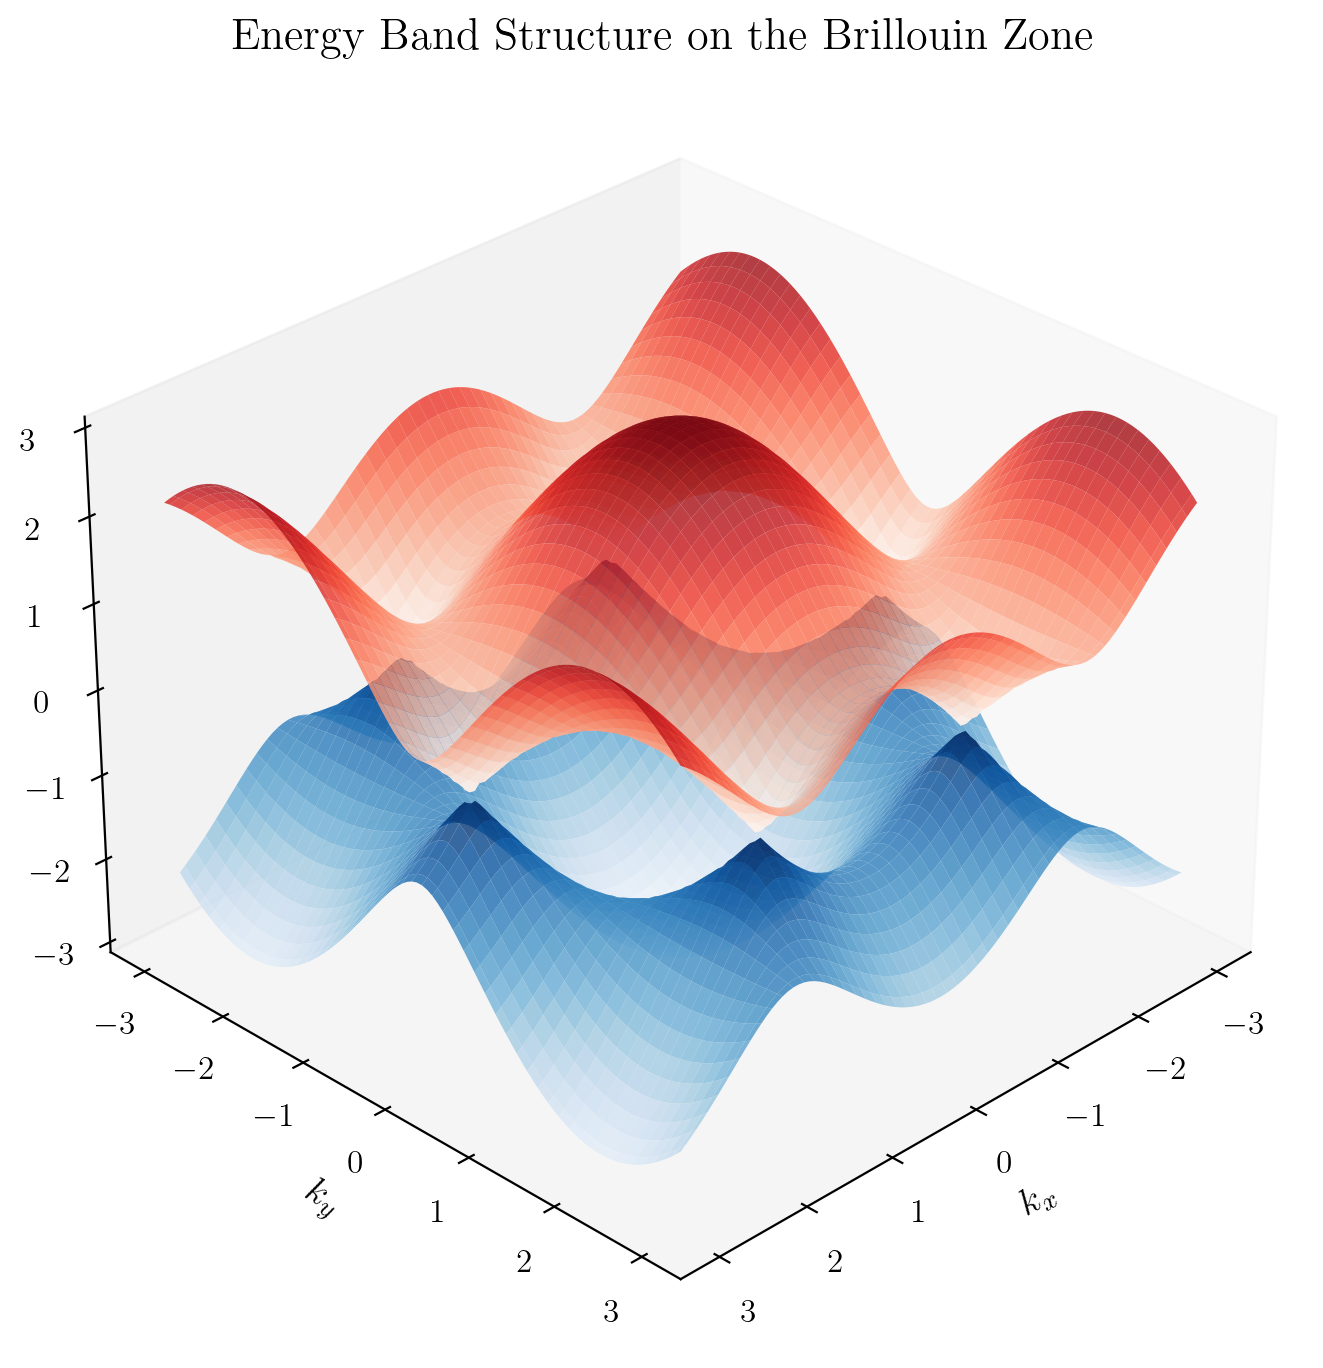

In [8]:
# 3D plot of the band structure over the whole BZ
from mpl_toolkits.mplot3d import Axes3D
kx = np.linspace(-3, 3, 100)
ky = np.linspace(-3, 3, 100)
KX, KY = np.meshgrid(kx, ky)

E_plus = np.zeros(KX.shape)
E_minus = np.zeros(KX.shape)
for i in range(KX.shape[0]):
    for j in range(KX.shape[1]):
        E_vals = energies(KX[i,j], KY[i,j])
        E_minus[i,j] = E_vals[0]
        E_plus[i,j] = E_vals[1]
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KX, KY, E_plus, cmap='Reds', alpha=0.8)
ax.plot_surface(KX, KY, E_minus, cmap='Blues', alpha=0.8)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_zlabel(r'$E(\mathbf{k})$')
ax.grid(False)
ax.set_title('Energy Band Structure on the Brillouin Zone',
             fontsize=16)
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()
